# CCLE 2019

The Cancer Cell Line Encyclopedia (CCLE) is a comprehensive resource of human cancer cell lines derived from various tissue types. These cell lines are cultured to proliferate indefinitely under in vitro conditions.

Developed primarily by the Broad Institute in collaboration with Novartis and other partners, CCLE aims to advance cancer biology research and drug discovery.

The collection enables large-scale drug screening and genomic studies, as the continuous proliferation of cell lines allows researchers to track genetic changes over time. However, a major limitation is the absence of the tumor microenvironment, which can affect translational relevance. Despite this, CCLE remains a cornerstone in cancer research and the development of precision medicine.



## Roadmap

In this notebook, we will analyze two different cancer cell lines using data from the **Cancer Cell Line Encyclopedia (CCLE)**.

We obtained both expression and mutation data from **cBioPortal** by querying the CCLE dataset and downloading the following files:

- `data_mutations.txt`: Contains information about all gene mutations in the samples.  
- `data_mrna_seq_rpkm.txt`: Contains gene expression data in RPKM units, with genes as rows and samples as columns.

### Analysis Pipeline

For each dataset, we will follow the steps below:

1. **Methodology Overview**  
   - Outline the analytical approach and preprocessing strategy.

2. **Sample Analysis**  
   - Evaluate quality control (QC) metrics for samples.  
   - Filter out low-quality or incomplete samples.  
   - Visualize sample distributions and characteristics.

3. **Gene Analysis**  
   - Assess QC metrics for genes.  
   - Apply appropriate gene filtering.  
   - Explore overall expression trends.

4. **Dimensionality Reduction**  
   - Reduce data to 2D using techniques like PCA or t-SNE.  
   - Investigate linear separability and detect batch effects.

5. **Data Preparation for Classification**  
   - Merge mutation and expression datasets.  
   - Detect and correct for batch effects.  
   - Format the cleaned dataset for downstream classification tasks.


## Imports and Auxiliary Functions

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.manifold import TSNE
from scipy.stats import skew, kurtosis
from sklearn.decomposition import PCA
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.model_selection import train_test_split
import warnings


warnings.filterwarnings('ignore')

In [2]:
def plot_violin_metrics(data, axis):
    """
    Plot violin plots of various QC metrics across genes or samples.

    Parameters:
        data (pd.DataFrame): Gene expression matrix (genes x samples)
        axis (int): 0 for sample-wise metrics, 1 for gene-wise metrics
    """
    axis_name = "Genes" if axis == 1 else "Samples"
    stats = {
        'Total Counts': data.sum(axis=axis),
        'Mean': data.mean(axis=axis),
        'Median': data.median(axis=axis),
        'Standard Deviation': data.std(axis=axis),
        'Coefficient of Variation': data.std(axis=axis) / data.mean(axis=axis),
        'Total Features': data.astype(bool).sum(axis=axis)
    }

    fig, ax = plt.subplots(1, len(stats), figsize=(25, 12))
    colors = ['firebrick', 'steelblue', 'orange', 'darkgreen', 'indigo', 'silver']

    for i, (metric, values) in enumerate(stats.items()):
        sns.violinplot(y=values.reset_index(drop=True), ax=ax[i], color=colors[i])
        ax[i].set_title(f'{metric} Across {axis_name}')
        ax[i].set_xlabel('')
        ax[i].grid(True)

        print(f'Max {metric.lower()}: {values.max():.2f} | Min {metric.lower()}: {values.min():.2f} | Range: {(values.max() - values.min()):.2f}')

    plt.tight_layout()
    plt.show()

def plot_skewness_kurtosis(data, axis):
    """
    Plot skewness and excess kurtosis for gene/sample expression.

    Parameters:
        data (pd.DataFrame): Gene expression matrix (genes x samples)
        axis (int): 0 for sample-wise, 1 for gene-wise
    """
    skew_vals = data.apply(skew, axis=axis)
    kurt_vals = data.apply(kurtosis, axis=axis)

    target = "Sample" if axis == 0 else "Gene"

    # Print summaries
    print(f"\nSummary of Skewness per {target}:")
    print(skew_vals.describe())
    print(f"\nSummary of Kurtosis per {target}:")
    print(kurt_vals.describe())

    # Plot
    plt.figure(figsize=(16, 5))

    # Skewness plot
    plt.subplot(1, 2, 1)
    plt.scatter(range(len(skew_vals)), skew_vals.values, s=3, color='mediumpurple')
    plt.title(f"Skewness of Expression per {target}")
    plt.xlabel(f"{target} Index")
    plt.ylabel("Skewness")
    plt.grid(True)

    # Kurtosis plot
    plt.subplot(1, 2, 2)
    plt.scatter(range(len(kurt_vals)), kurt_vals.values, s=3, color='darkorange')
    plt.title(f"Excess Kurtosis per {target}")
    plt.xlabel(f"{target} Index")
    plt.ylabel("Kurtosis")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def heatmap_plot(title, data, samples):
    """
    Plot Pearson correlation heatmap between samples.

    Parameters:
        title (str): Title of the plot
        data (pd.DataFrame): Gene expression matrix (genes x samples)
        samples (list): Subset of sample column names to include in the heatmap
    """
    plt.figure(figsize=(10, 8))
    plt.title(title)
    sns.heatmap(data.loc[:, samples].corr(), cmap='viridis', annot=False)
    plt.show()
    print(f"Number of samples plotted: {len(samples)} x {len(samples)}")


def plot_PCA_tsne_umap(data_ordered, mutated_samples, non_mutated_samples, title, categories):
    """
    Generates a combined plot of PCA, t-SNE, and UMAP visualizations for given data.

    Parameters:
    - data_ordered: pandas DataFrame or array-like, features x samples matrix
    - mutated_samples: list of sample identifiers for mutated samples
    - non_mutated_samples: list of sample identifiers for non-mutated samples
    - title: str, overall title for the figure
    - categories: tuple of two strings (mutated_label, non_mutated_label)
    """
    # Build labels and colors
    mutation_status = [categories[0]] * len(mutated_samples) + [categories[1]] * len(non_mutated_samples)
    label_map = {categories[0]: 0, categories[1]: 1}
    color_values = [label_map[label] for label in mutation_status]

    # Convert data: transpose to samples x features
    X = data_ordered.T.to_numpy() 

    # PCA
    pca = PCA(n_components=2, random_state=42)
    pca_result = pca.fit_transform(X)

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, learning_rate='auto', init='random')
    tsne_result = tsne.fit_transform(X)

    # UMAP
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_result = reducer.fit_transform(X)

    # Plotting
    plt.figure(figsize=(18, 5))

    # PCA subplot
    plt.subplot(1, 3, 1)
    plt.scatter(pca_result[:, 0], pca_result[:, 1], c=color_values, cmap='viridis', alpha=0.8)
    plt.title('PCA: {} vs {}'.format(categories[0], categories[1]))
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.grid(True)

    # t-SNE subplot
    plt.subplot(1, 3, 2)
    plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=color_values, cmap='viridis', alpha=0.8)
    plt.title('t-SNE: {} vs {}'.format(categories[0], categories[1]))
    plt.xlabel('tSNE1')
    plt.ylabel('tSNE2')
    plt.grid(True)

    # UMAP subplot
    plt.subplot(1, 3, 3)
    plt.scatter(umap_result[:, 0], umap_result[:, 1], c=color_values, cmap='viridis', alpha=0.8)
    plt.title('UMAP: {} vs {}'.format(categories[0], categories[1]))
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    plt.grid(True)

    # Legend and overall title
    handles = [plt.Line2D([], [], marker='o', linestyle='', color=plt.cm.viridis(label_map[c]/1), label=c)
               for c in categories]
    plt.legend(handles=handles, title='Category', loc='upper right')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def standard(df):
    """
    Standardize expression values (zero mean, unit variance) across each feature.

    Parameters:
        df (pd.DataFrame): Gene expression matrix (genes x samples)

    Returns:
        pd.DataFrame: Standardized expression matrix
    """
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df.T).T  # Scale features (genes), not samples
    return pd.DataFrame(scaled, index=df.index, columns=df.columns)

## Data Collection

In [3]:
mRNA_path = '../DATA/ccle_2019/data_mrna_seq_rpkm.txt'
mRNA_2019 = pd.read_csv(mRNA_path, sep='\t', comment='#')
mut_path = '../DATA/ccle_2019/data_mutations.txt'
mut_all_2019 = pd.read_csv(mut_path, sep='\t', comment='#')

In [4]:
mRNA_2019.head()

,Hugo_Symbol,22RV1_PROSTATE,2313287_STOMACH,253JBV_URINARY_TRACT,253J_URINARY_TRACT,42MGBA_CENTRAL_NERVOUS_SYSTEM,5637_URINARY_TRACT,59M_OVARY,639V_URINARY_TRACT,647V_URINARY_TRACT,...,UMUC16_URINARY_TRACT,UMUC4_URINARY_TRACT,UMUC5_URINARY_TRACT,UMUC6_URINARY_TRACT,UMUC7_URINARY_TRACT,UMUC9_URINARY_TRACT,UPCISCC152_UPPER_AERODIGESTIVE_TRACT,UW228_CENTRAL_NERVOUS_SYSTEM,Y79_AUTONOMIC_GANGLIA,YAMATO_SOFT_TISSUE
0,DDX11L1,0.00000,0.03755,0.00000,0.06507,0.00000,0.01378,0.01463,0.03085,0.00000,...,0.00000,0.02977,0.02999,0.03532,0.03831,0.03236,0.00000,0.03799,0.02907,0.00000
1,WASH7P,12.63011,10.14155,6.20657,6.55835,7.61752,6.19356,4.62277,6.00767,4.70699,...,6.42321,8.17443,7.75149,9.97036,8.17080,8.70551,15.23348,6.47732,8.45568,11.81688
2,MIR1302-11,0.04289,0.01037,0.16955,0.23364,0.08765,0.00000,0.00808,0.09373,0.02568,...,0.12367,0.19183,0.10492,0.18537,0.07408,0.07747,0.07448,0.01049,0.39607,0.17586
3,FAM138A,0.00000,0.00869,0.22423,0.16558,0.00000,0.00637,0.00000,0.01427,0.00000,...,0.01554,0.00459,0.01850,0.04903,0.01330,0.00000,0.02674,0.00879,0.26449,0.02266
4,OR4G4P,0.00000,0.00000,0.02886,0.03875,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00667,0.01182,0.01786,0.01052,0.01141,0.00642,0.00000,0.00000,0.00000,0.01459


In [5]:
mut_all_2019.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,RNAseq_AC,SangerRecalibWES_AC,SangerWES_AC,TCGAhsCnt,WES_AC,WGS_AC,cDNA_Change,isCOSMIChotspot,isDeleterious,isTCGAhotspot
0,DVL1,1855,NaN,GRCh37,1,1277461,1277461,+,synonymous_variant,Silent,...,NaN,NaN,NaN,0,87:39,NaN,c.438G>A,False,False,False
1,AL590822.1,0,NaN,GRCh37,1,2144416,2144416,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,0,23:43,NaN,c.604C>T,False,False,False
2,PLCH2,9651,NaN,GRCh37,1,2435359,2435359,+,3_prime_UTR_variant,3'UTR,...,NaN,NaN,NaN,0,9:25,NaN,NaN,False,True,False
3,UBE4B,10277,NaN,GRCh37,1,10177641,10177641,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,0,13:95,NaN,c.934G>A,False,False,False
4,SRM,6723,NaN,GRCh37,1,11119363,11119363,+,synonymous_variant,Silent,...,NaN,NaN,NaN,0,113:57,NaN,c.207C>A,False,False,False


In [6]:
mRNA_2019.set_index('Hugo_Symbol', inplace=True)

# Merge duplicate genes by averaging expression values
mRNA_2019 = mRNA_2019.groupby(mRNA_2019.index).mean()

# Filter only TP53 mutations
mut_all_2019 = mut_all_2019[mut_all_2019['Hugo_Symbol'] == 'TP53']

# Keep only sample ID and mutation type
mut_all_2019 = mut_all_2019[['Tumor_Sample_Barcode', 'Variant_Type']]
mut_all_2019.set_index('Tumor_Sample_Barcode', inplace=True)

# --------- Filter Inconsistent Mutation Annotations ---------
variant_check = mut_all_2019.groupby(mut_all_2019.index)["Variant_Type"].nunique()
consistent_samples = variant_check[variant_check == 1].index
inconsistent_samples = variant_check[variant_check != 1].index

# Keep only consistent mutation samples
mut_all_2019 = mut_all_2019.loc[consistent_samples]

# Drop inconsistent samples from mRNA data
mRNA_2019 = mRNA_2019.drop(columns=[col for col in inconsistent_samples if col in mRNA_2019.columns])

# Remove duplicates (keep one mutation type per sample)
mut_all_2019 = mut_all_2019[~mut_all_2019.index.duplicated(keep='first')]

# --------- Create Wild-Type (WT) Annotations ---------
all_samples = set(mRNA_2019.columns)
mutated_samples = set(mut_all_2019.index)
wt_samples = all_samples - mutated_samples

# Assign 'WT' to those samples
wt_df = pd.DataFrame(index=list(wt_samples))
wt_df['Variant_Type'] = 'WT'

# Combine WT and Mutated samples
mut_all_2019 = pd.concat([mut_all_2019, wt_df])

# Reorder to match mRNA sample columns
mut_all_2019 = mut_all_2019.loc[mRNA_2019.columns]

# --------- Final Output (Optional) ---------
# You now have:
# - `mRNA_2019`: gene expression matrix (genes x samples)
# - `mut_all_2019`: TP53 mutation status per sample (with 'WT')

# Example: inspect how many samples are WT vs Mutated
print(mut_all_2019['Variant_Type'].value_counts())


Variant_Type
SNP    625
WT     402
DEL     70
INS     18
DNP      2
Name: count, dtype: int64


In [7]:
print(f'Zero entries: {(mRNA_2019 == 0).sum().sum()}') # entries all positive no zeros
print("The sparsity of the data is due to the fact that the technique used to measure the expression is bulk RNAseq")

Zero entries: 28856037
The sparsity of the data is due to the fact that the technique used to measure the expression is bulk RNAseq


## Filtering

In [8]:
mutated_samples = mut_all_2019[mut_all_2019['Variant_Type'] != 'WT'].index
non_mutated_samples = mut_all_2019[mut_all_2019['Variant_Type'] == 'WT'].index


random_samples_mut_100 = np.random.choice(mutated_samples,size = 100)
random_samples_non_mut_100 = np.random.choice(non_mutated_samples,size = 100)
random_samples_mut_50_non_mut50 = list(random_samples_mut_100[:50]) + list(random_samples_non_mut_100[:50])

Let us see how the mutations are distributed

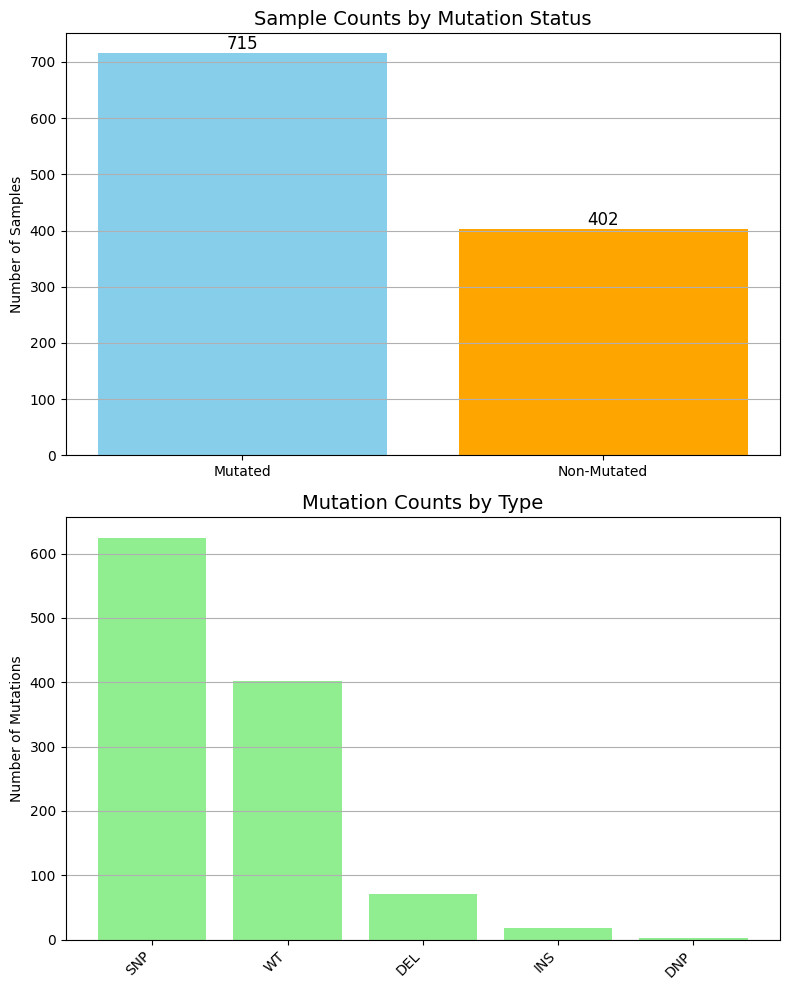

In [9]:
# --- Plot Sample Counts and Mutation Types ---

# Data: Count of mutated and non-mutated samples
sample_counts = [len(mutated_samples), len(non_mutated_samples)]

# Data: Count of mutation types
mutation_counts = mut_all_2019['Variant_Type'].value_counts()

# Create subplots (2 rows, 1 column)
fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# --- Plot 1: Mutated vs Non-Mutated Sample Counts ---
axs[0].bar(['Mutated', 'Non-Mutated'], sample_counts, color=['skyblue', 'orange'])
axs[0].set_title("Sample Counts by Mutation Status", fontsize=14)
axs[0].set_ylabel("Number of Samples")
axs[0].grid(True, axis='y')

# Add count labels above bars
for i, count in enumerate(sample_counts):
    axs[0].text(i, count + 1, str(count), ha='center', va='bottom', fontsize=12)

# --- Plot 2: Mutation Counts by Type ---
axs[1].bar(mutation_counts.index, mutation_counts.values, color='lightgreen')
axs[1].set_title("Mutation Counts by Type", fontsize=14)
axs[1].set_ylabel("Number of Mutations")
axs[1].set_xticks(range(len(mutation_counts)))
axs[1].set_xticklabels(mutation_counts.index, rotation=45, ha='right')
axs[1].grid(True, axis='y')

# Layout adjustment
plt.tight_layout()
plt.show()

Can we find correlations in the samples?

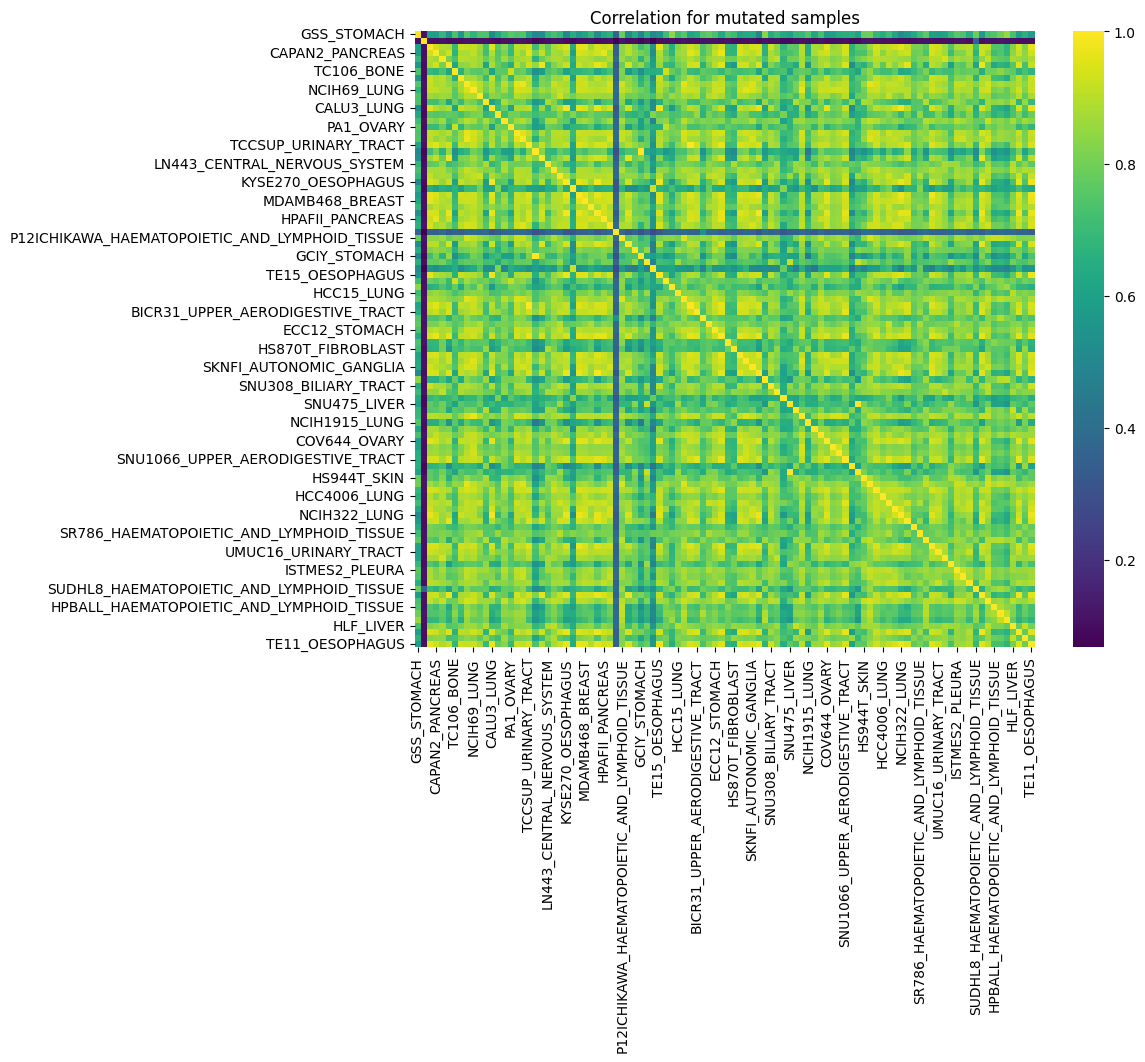

Number of samples plotted: 100 x 100


In [10]:
heatmap_plot('Correlation for mutated samples',mRNA_2019,random_samples_mut_100)

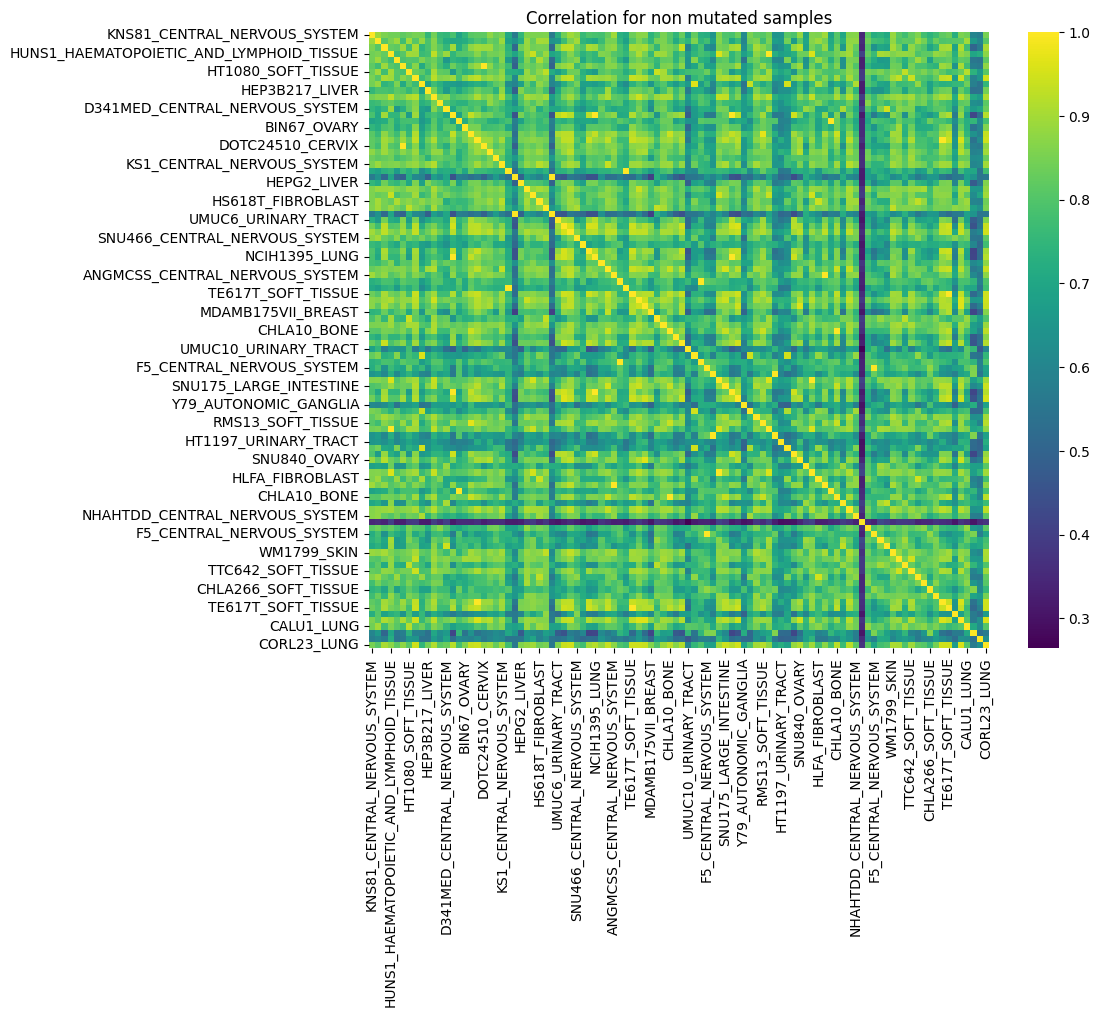

Number of samples plotted: 100 x 100


In [11]:
heatmap_plot('Correlation for non mutated samples',mRNA_2019,random_samples_non_mut_100)

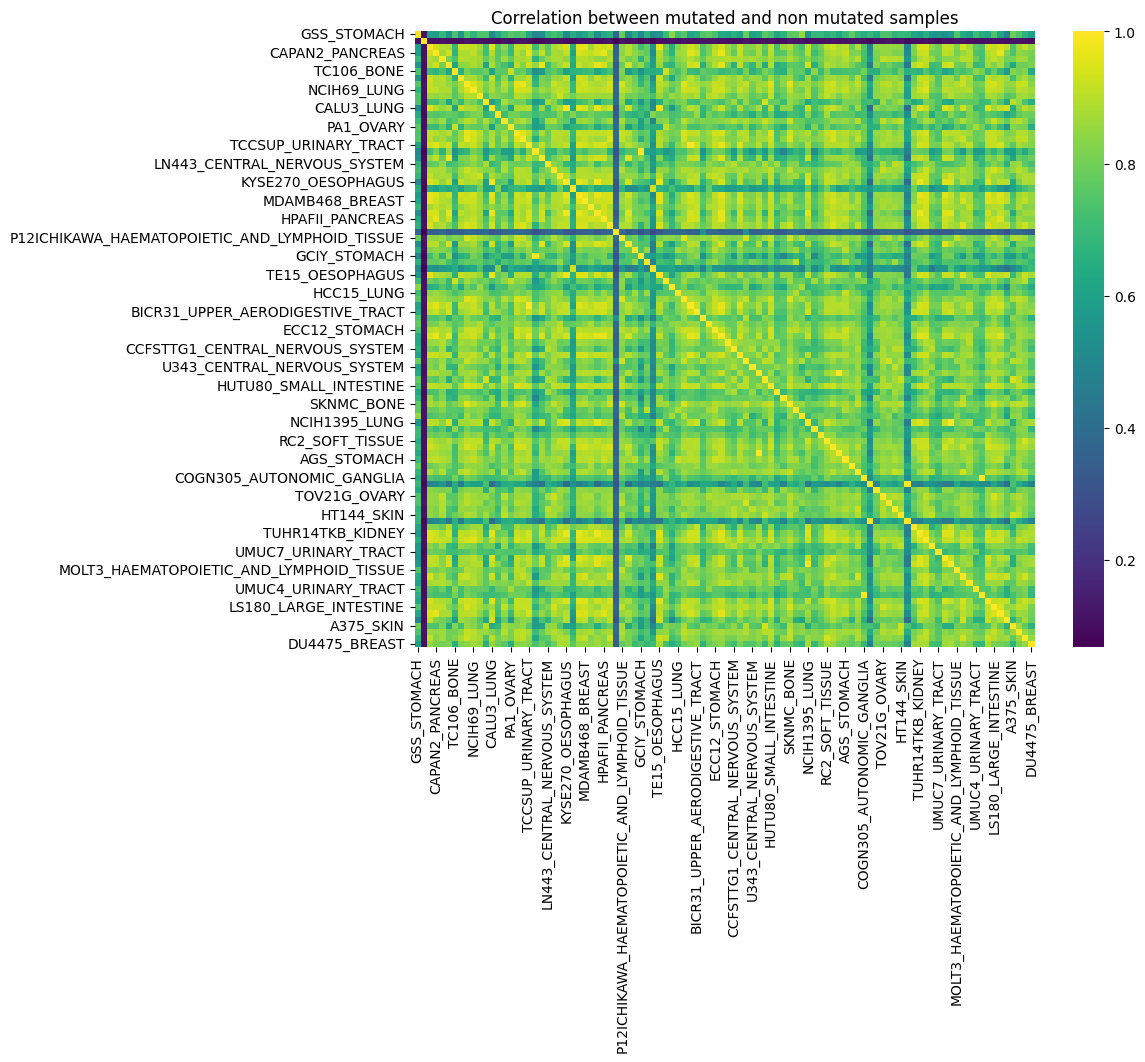

Number of samples plotted: 100 x 100


In [12]:
heatmap_plot('Correlation between mutated and non mutated samples',mRNA_2019,random_samples_mut_50_non_mut50)

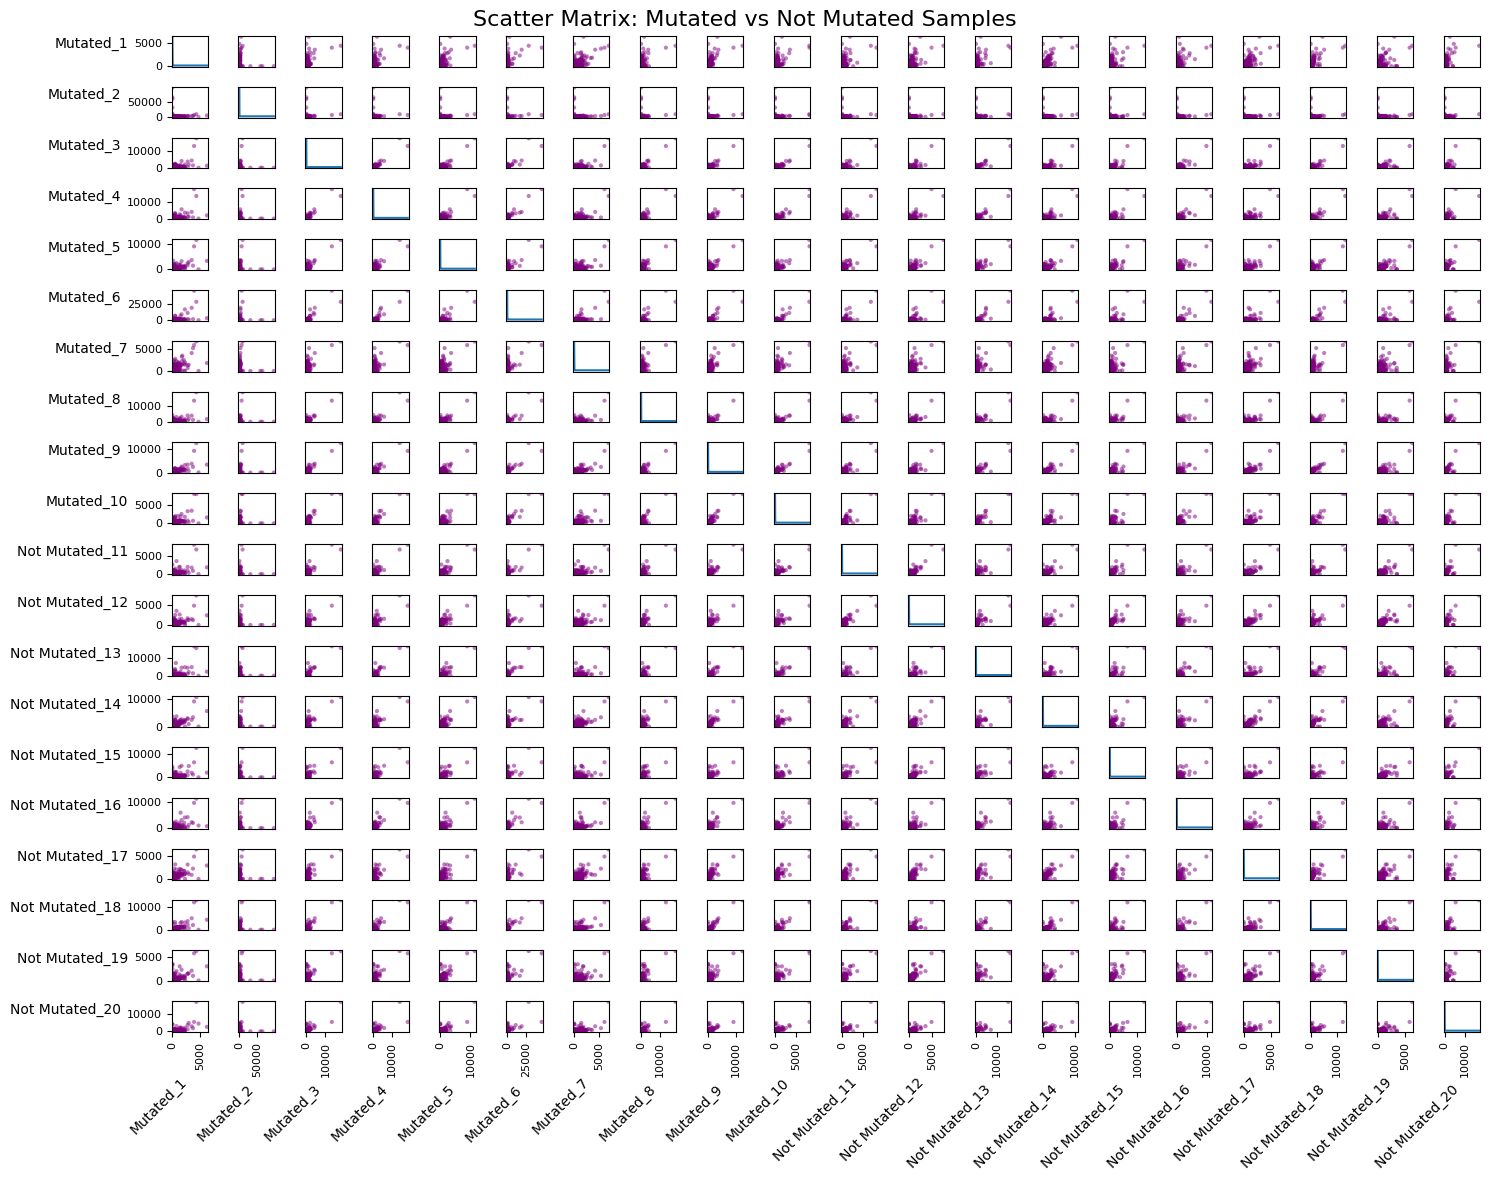

In [13]:
# --- Select and Prepare Sample Subset for Scatter Matrix ---

# Combine 10 mutated and 10 non-mutated sample IDs
selected_ids = random_samples_mut_100[:10].tolist() + random_samples_non_mut_100[:10].tolist()

# Subset expression data for selected samples
subset_expr = mRNA_2019.loc[:, selected_ids]

# Rename columns for clarity (e.g., Mutated_1, Not Mutated_1, etc.)
labels = ['Mutated'] * 10 + ['Not Mutated'] * 10
subset_expr.columns = [f"{label}_{i+1}" for i, label in enumerate(labels)]

# Generate scatter matrix
axes = scatter_matrix(subset_expr, diagonal='kde', figsize=(15, 12), color='purple')

# Rotate x and y axis labels for readability
for ax in axes.ravel():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right')
        ax.set_ylabel(ax.get_ylabel(), rotation=0, ha='right')

# Final touches
plt.suptitle("Scatter Matrix: Mutated vs Not Mutated Samples", fontsize=16)
plt.tight_layout()
plt.show()


In [14]:
# --- Correlation Summary for Mutated and Non-Mutated Samples ---

def print_correlation_stats(group_name, sample_ids, data):
    corr_matrix = data.loc[:, sample_ids].corr()
    stats = corr_matrix.describe()
    
    print(f"---- {group_name} Samples ----")
    print(f"1) Minimum pairwise correlation: {stats.loc['min'].min():.4f}")
    print(f"2) Minimum average correlation per sample: {stats.loc['mean'].min():.4f}\n")

# Mutated Samples
print_correlation_stats("Mutated", mutated_samples, mRNA_2019)

# Non-Mutated Samples
print_correlation_stats("Non-Mutated", non_mutated_samples, mRNA_2019)

---- Mutated Samples ----
1) Minimum pairwise correlation: 0.0224
2) Minimum average correlation per sample: 0.1140

---- Non-Mutated Samples ----
1) Minimum pairwise correlation: 0.0620
2) Minimum average correlation per sample: 0.2019




Summary of Skewness per Sample:
count    1117.000000
mean       83.103049
std        27.702455
min        27.516557
25%        62.400892
50%        80.469855
75%       103.726019
max       195.136608
dtype: float64

Summary of Kurtosis per Sample:
count     1117.000000
mean     10000.435200
std       5619.562431
min       1045.460708
25%       5680.300505
50%       9067.694424
75%      13484.131062
max      41197.119994
dtype: float64


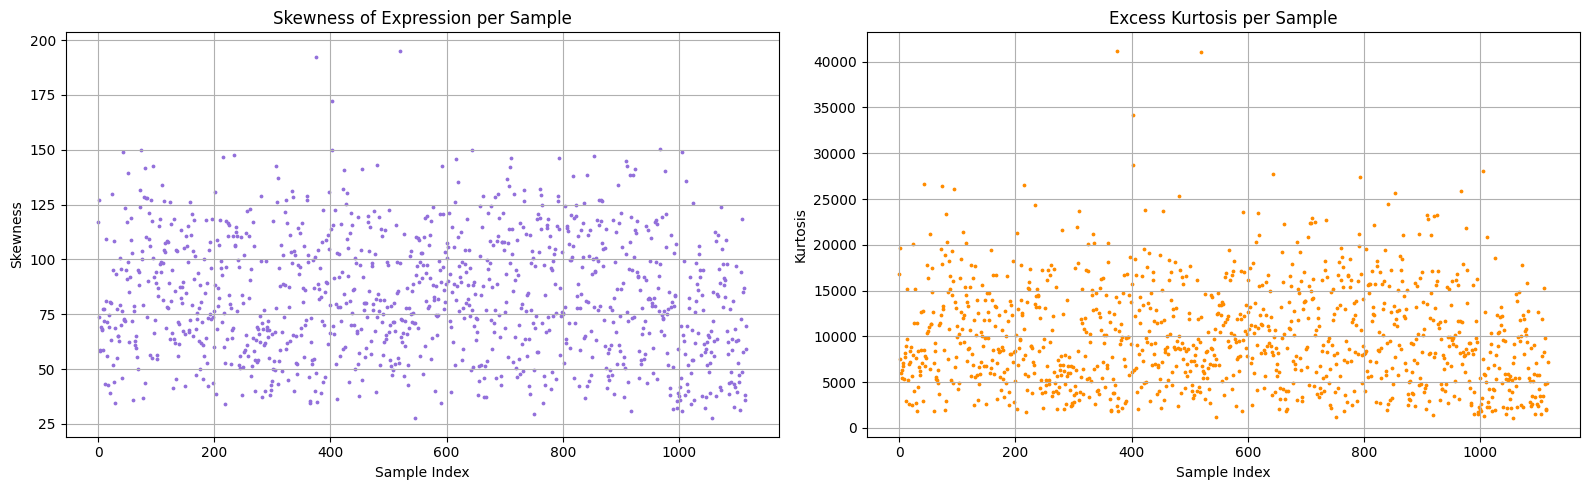

In [16]:
plot_skewness_kurtosis(mRNA_2019,0)

#### Skewness and Kurtosis Analysis

Both **skewness** and **kurtosis** are positive across all samples:

- **Positive skewness** indicates that the distribution of gene expression values is **right-skewed** within each sample. This means that while most genes have low to moderate expression, a small number of genes exhibit **very high expression levels**. This pattern is expected in RNA-seq data normalized using **RPKM**, where a subset of genes dominates the overall expression landscape.

- **Positive excess kurtosis** suggests that the expression distributions are **leptokurtic** — characterized by **sharper peaks** and **heavier tails** than a normal distribution. In practical terms, this implies that expression values are more tightly clustered around the mean, but with a higher probability of **extreme expression values** occurring.

These characteristics reflect the **non-Gaussian nature** of gene expression data and underscore the importance of appropriate normalization and transformation techniques in downstream analyses.


Max total counts: 15841187.28 | Min total counts: 0.00 | Range: 15841187.28
Max mean: 14181.90 | Min mean: 0.00 | Range: 14181.90
Max median: 11340.85 | Min median: 0.00 | Range: 11340.85
Max standard deviation: 10592.80 | Min standard deviation: 0.00 | Range: 10592.80
Max coefficient of variation: 33.42 | Min coefficient of variation: 0.24 | Range: 33.18
Max total features: 1117.00 | Min total features: 0.00 | Range: 1117.00


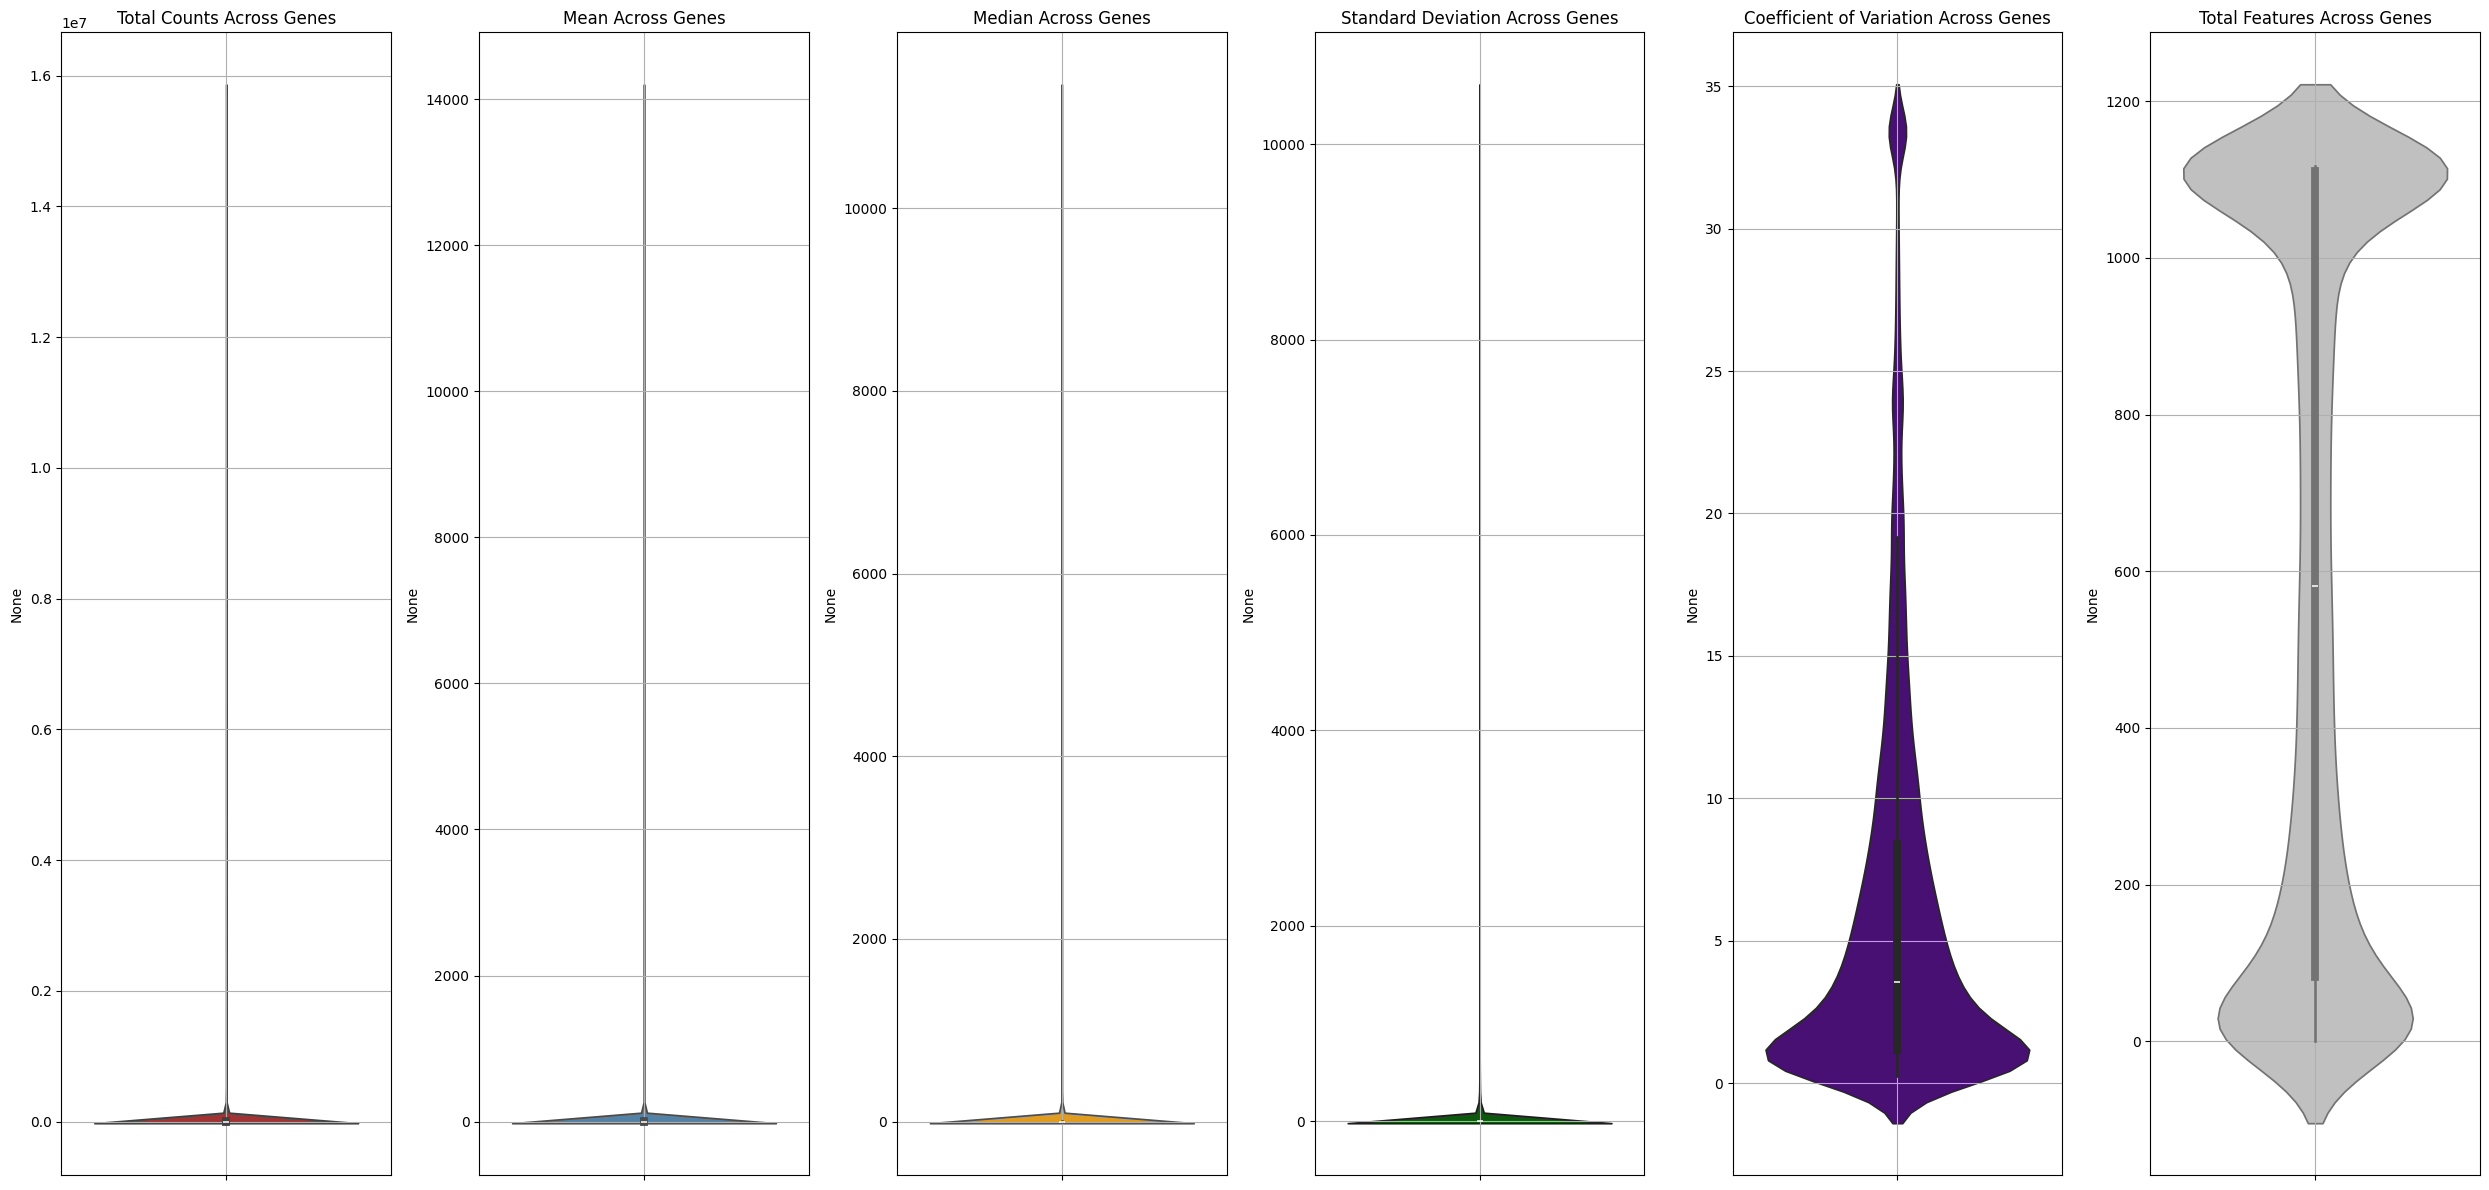

In [17]:
plot_violin_metrics(mRNA_2019,1)

Max total counts: 637183.70 | Min total counts: 278917.46 | Range: 358266.23
Max mean: 11.72 | Min mean: 5.13 | Range: 6.59
Max median: 0.11 | Min median: 0.00 | Range: 0.11
Max standard deviation: 695.88 | Min standard deviation: 43.63 | Range: 652.25
Max coefficient of variation: 63.58 | Min coefficient of variation: 6.62 | Range: 56.96
Max total features: 40815.00 | Min total features: 21619.00 | Range: 19196.00


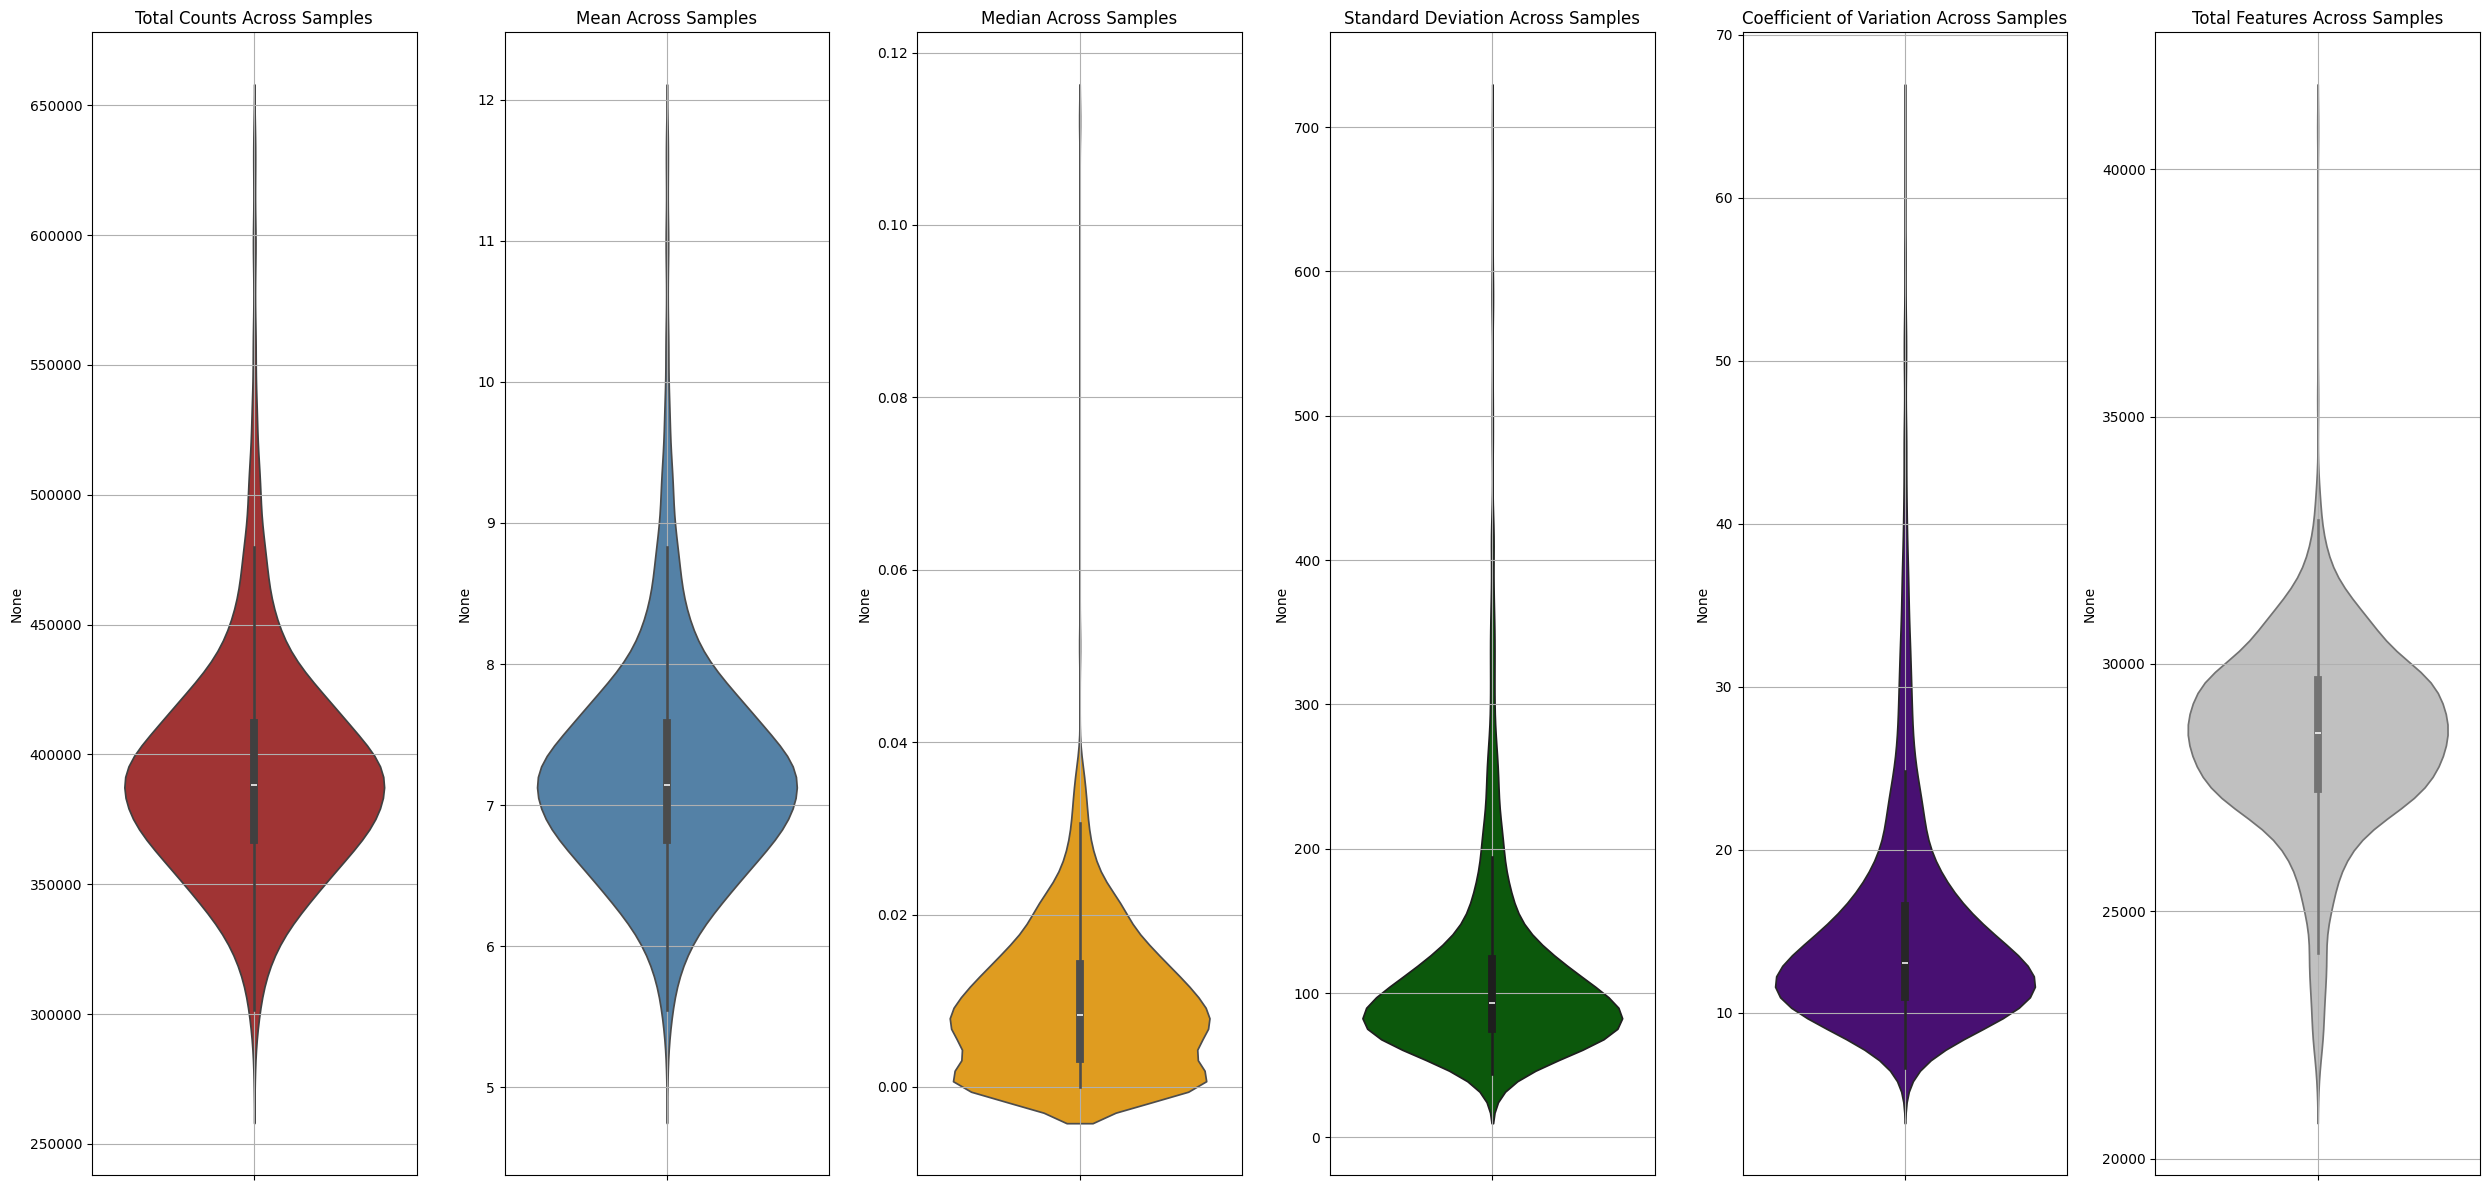

In [18]:
# Plot QC metrics
plot_violin_metrics(mRNA_2019,0)

#### Gene-Level Quality Control Summary

The violin plots and QC metrics reveal a highly skewed distribution of expression across genes:

- Several genes have **extremely high total and mean expression**, while many others have **zero or near-zero counts**. This is evident from the wide range in total counts (0 to over 15 million) and median expression (0 to over 11,000).
- The **standard deviation** and **coefficient of variation (CV)** also show large spreads, indicating **substantial variability** across the dataset.
- The **feature count** metric highlights that some genes are expressed in nearly all samples, while others have **no detectable expression at all**.

This pattern suggests the presence of a large number of **sparse or uninformative genes**, which can inflate noise and distort downstream analyses such as dimensionality reduction or classification.

To improve data quality and reduce unnecessary variation, we will apply **gene filtering** — specifically removing genes with consistently low or zero expression across samples.


In [19]:
cv_genes = mRNA_2019.std(axis = 1)/mRNA_2019.mean(axis = 1) 
genes_to_keep = cv_genes[(cv_genes > 0.05) & (cv_genes< 50)].index

# remove
mRNA_final = mRNA_2019.loc[genes_to_keep]

threshold = mRNA_final.shape[1]*(0.1)
genes_to_keep = mRNA_final.astype(bool).sum(axis=1)[mRNA_final.astype(bool).sum(axis=1) > threshold].index
mRNA_final = mRNA_final.loc[genes_to_keep]

What about distribution after filtering?

Max total counts: 15841187.28 | Min total counts: 0.53 | Range: 15841186.76
Max mean: 14181.90 | Min mean: 0.00 | Range: 14181.90
Max median: 11340.85 | Min median: 0.00 | Range: 11340.85
Max standard deviation: 10592.80 | Min standard deviation: 0.00 | Range: 10592.80
Max coefficient of variation: 33.30 | Min coefficient of variation: 0.24 | Range: 33.06
Max total features: 1117.00 | Min total features: 112.00 | Range: 1005.00


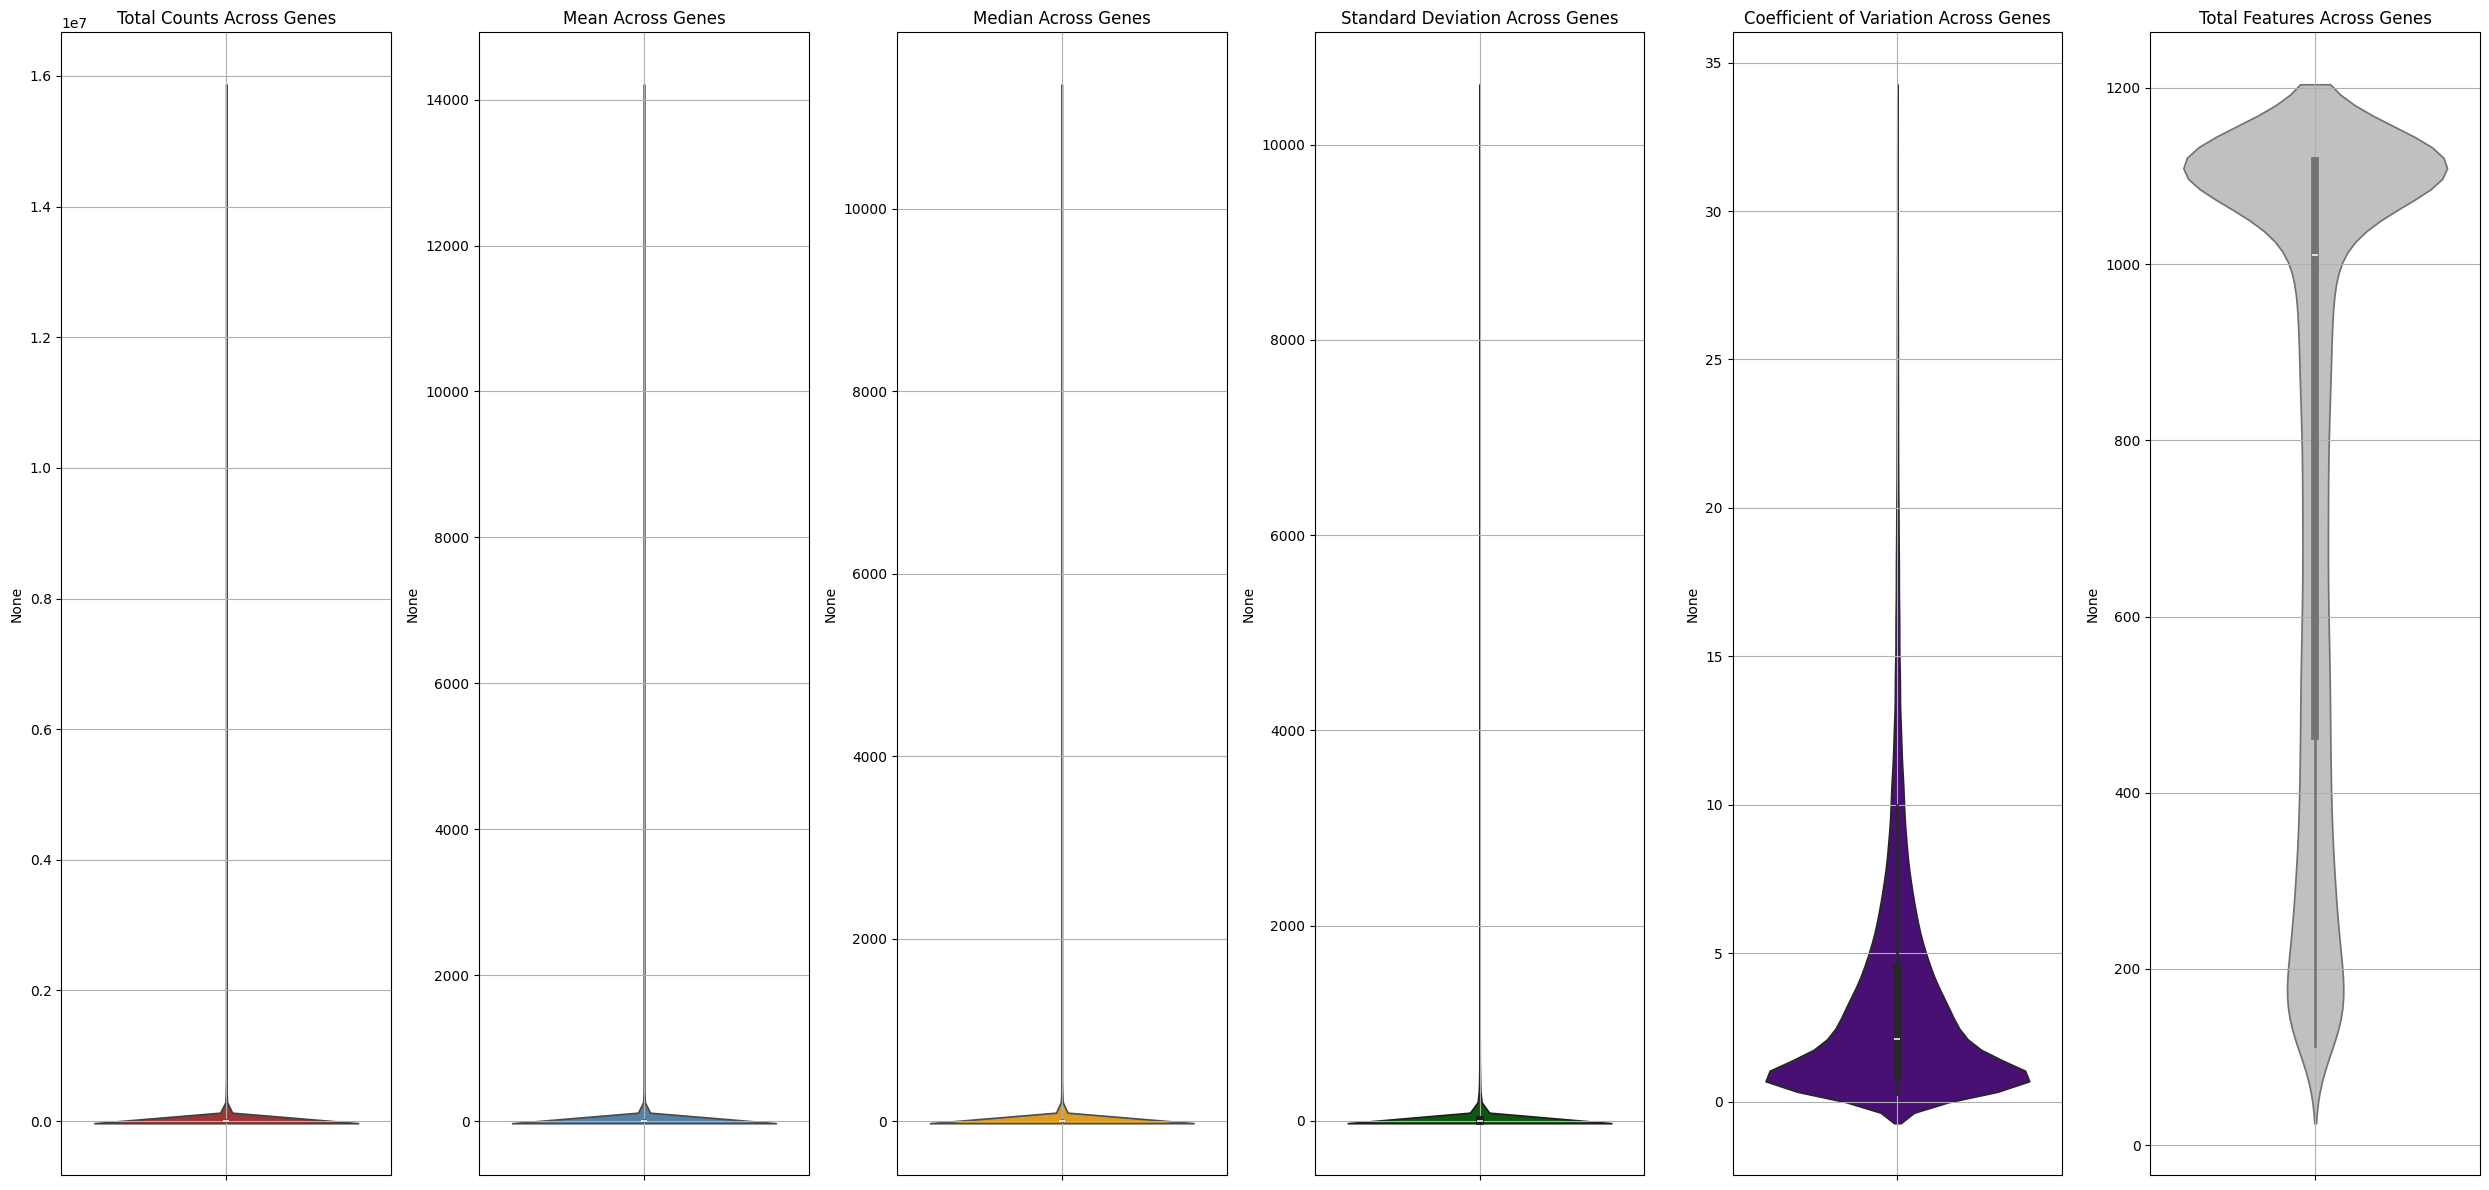

In [20]:
plot_violin_metrics(mRNA_final,1)

Max total counts: 636374.78 | Min total counts: 278805.03 | Range: 357569.75
Max mean: 16.30 | Min mean: 7.14 | Range: 9.16
Max median: 0.31 | Min median: 0.02 | Range: 0.29
Max standard deviation: 820.99 | Min standard deviation: 51.25 | Range: 769.75
Max coefficient of variation: 53.89 | Min coefficient of variation: 5.59 | Range: 48.30
Max total features: 35001.00 | Min total features: 21513.00 | Range: 13488.00


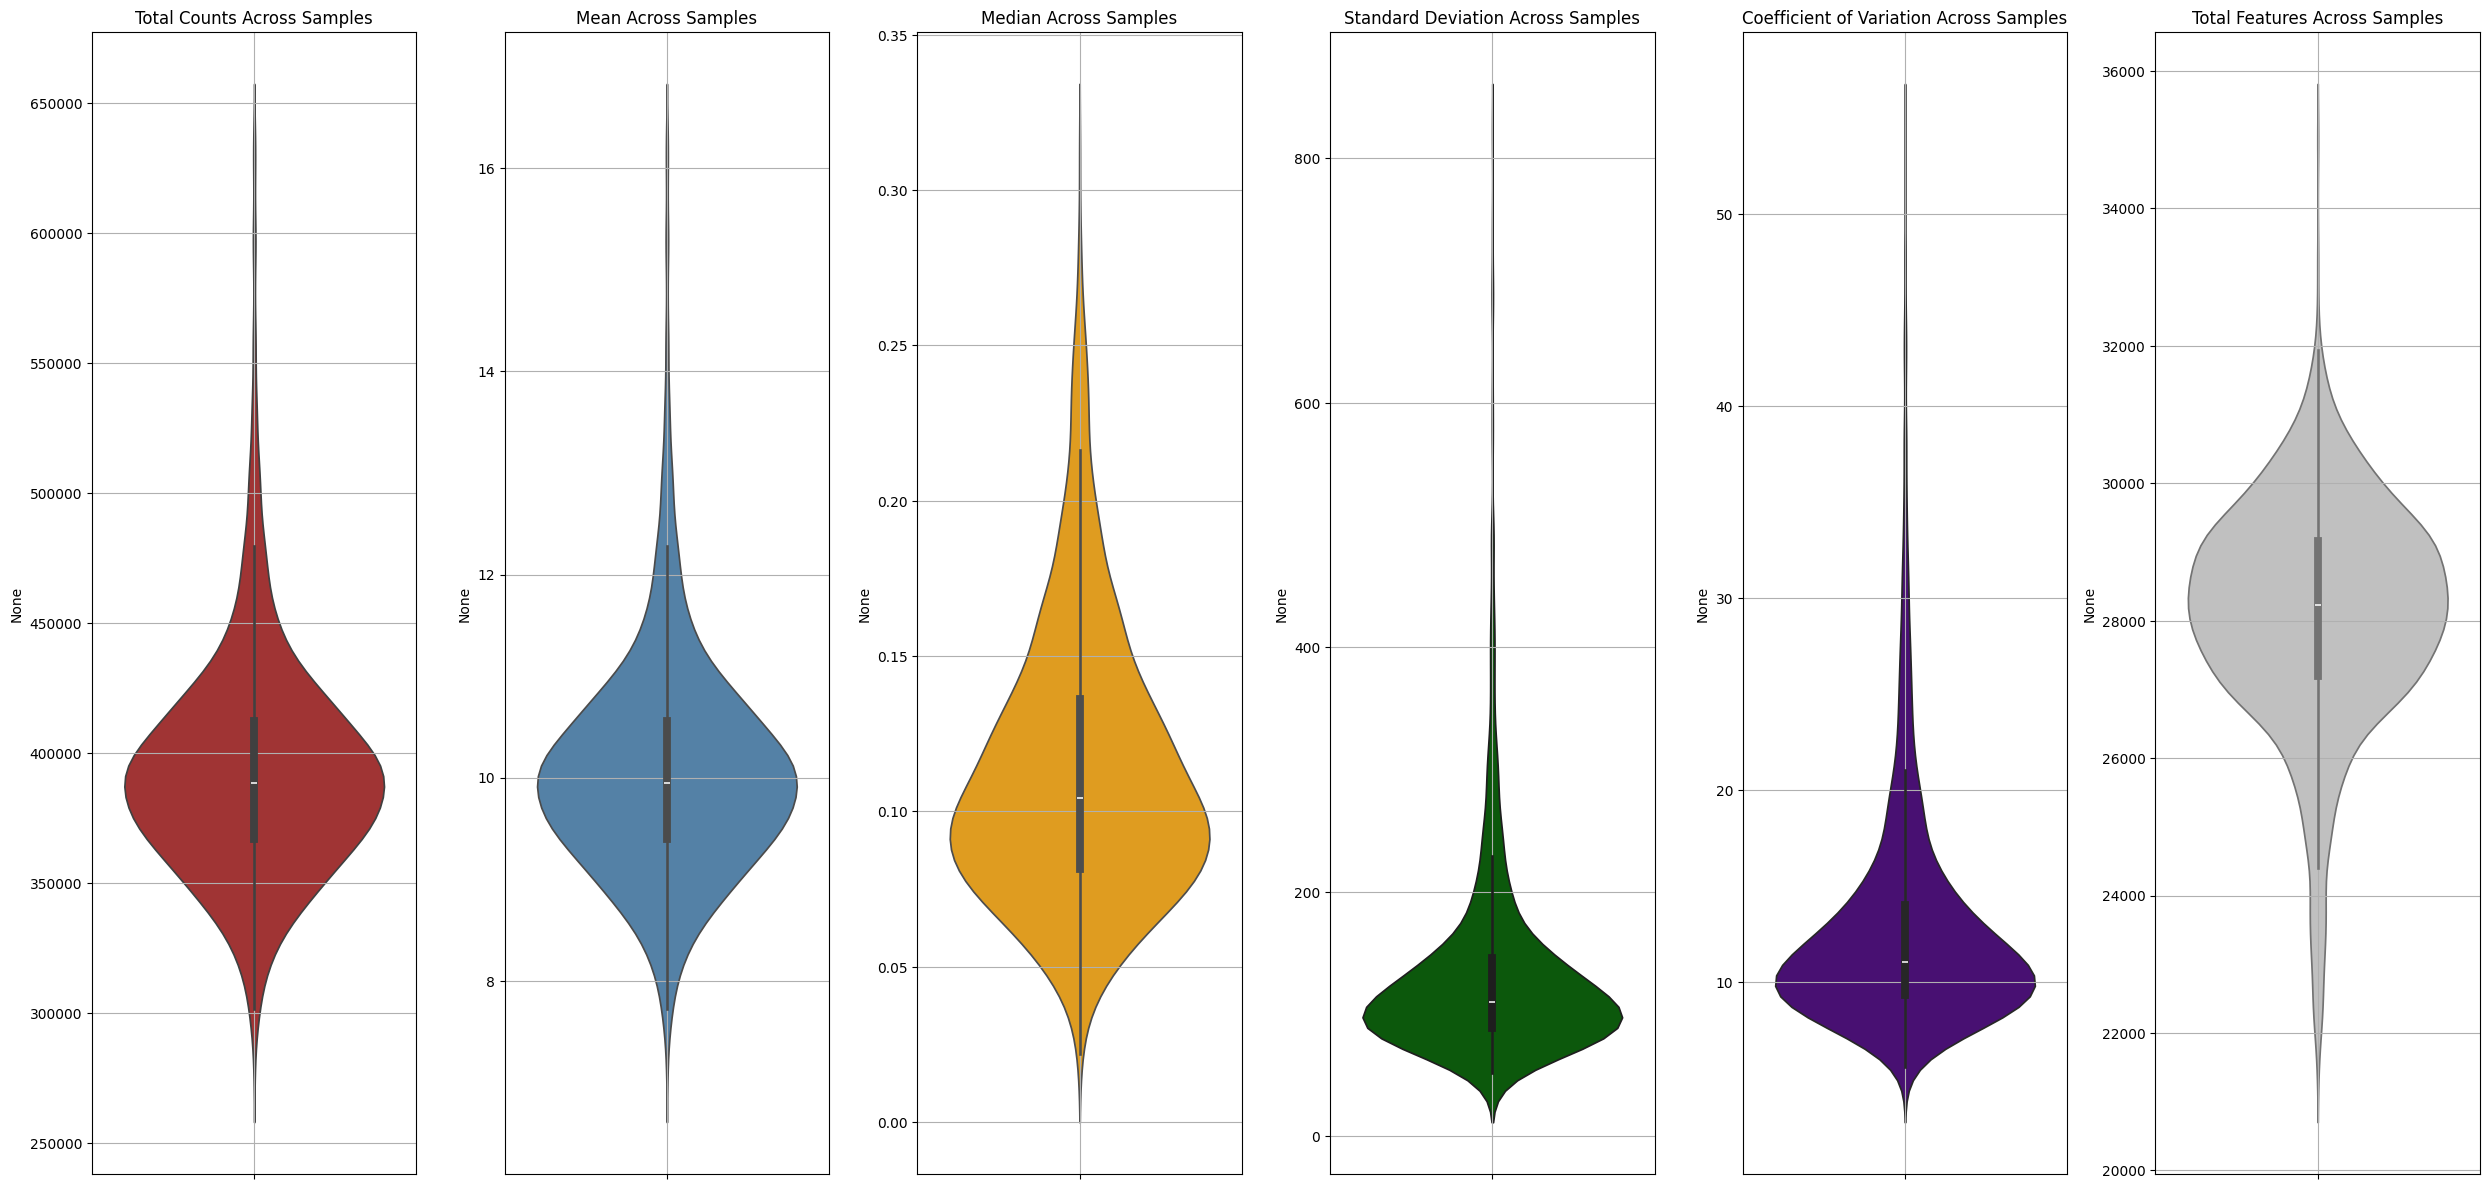

In [21]:
plot_violin_metrics(mRNA_final,0)

The updated filtering improved the dataset by removing low-quality genes while preserving signal:

- **Unexpressed genes removed**: Minimum total count went from 0.00 to 0.53.
- **Sparse genes filtered**: All retained genes are now expressed in at least 112 samples.
- **Less noise**: Max coefficient of variation dropped from 63.58 to 53.89.
- **Richer samples**: Median expression per sample is no longer zero; variability increased.


## Dimensionality Reduction

In [22]:
# Order samples by mutation status (mutated first, then non-mutated)
mRNA_2019_ordered = mRNA_2019[mutated_samples.tolist() + non_mutated_samples.tolist()]

# Apply log1p transformation to handle skewed distribution and reduce impact of extreme values
mRNA_2019_ordered_log = np.log1p(mRNA_2019_ordered)

# Standardize the log-transformed data to have zero mean and unit variance
mRNA_2019_scaled = standard(mRNA_2019_ordered_log)

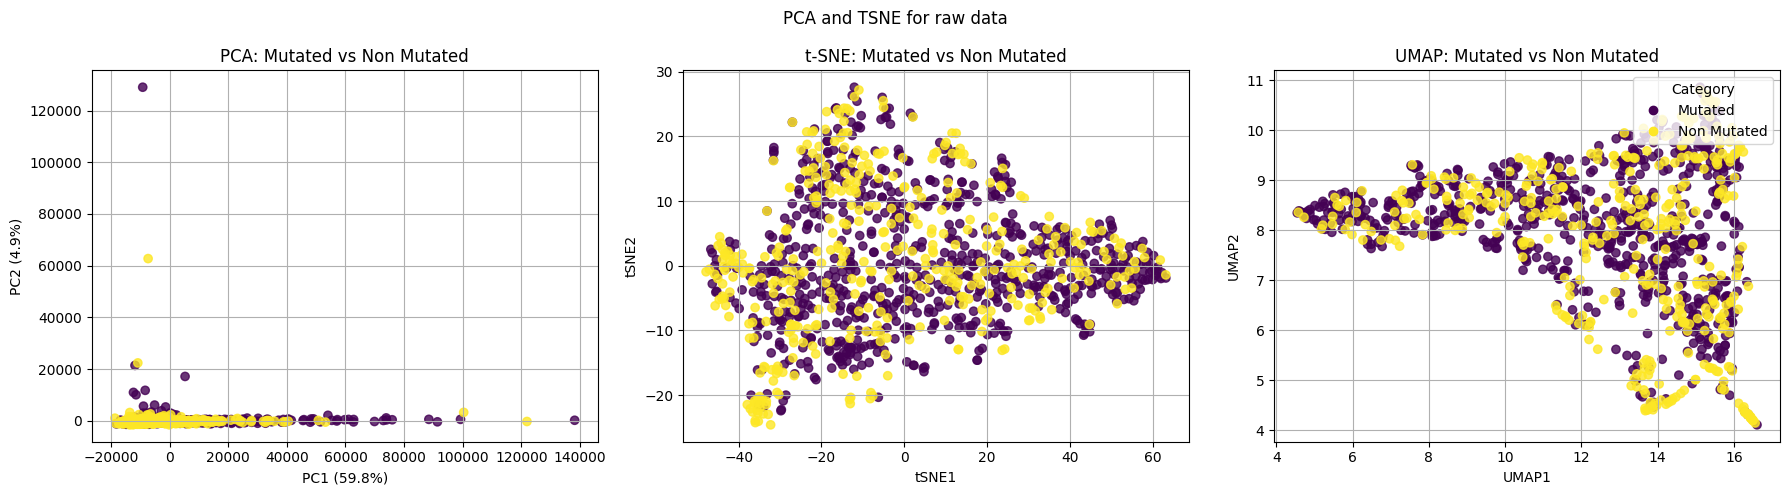

In [23]:
plot_PCA_tsne_umap(mRNA_2019_ordered,mutated_samples,non_mutated_samples,'PCA and TSNE for raw data', categories=['Mutated','Non Mutated'])

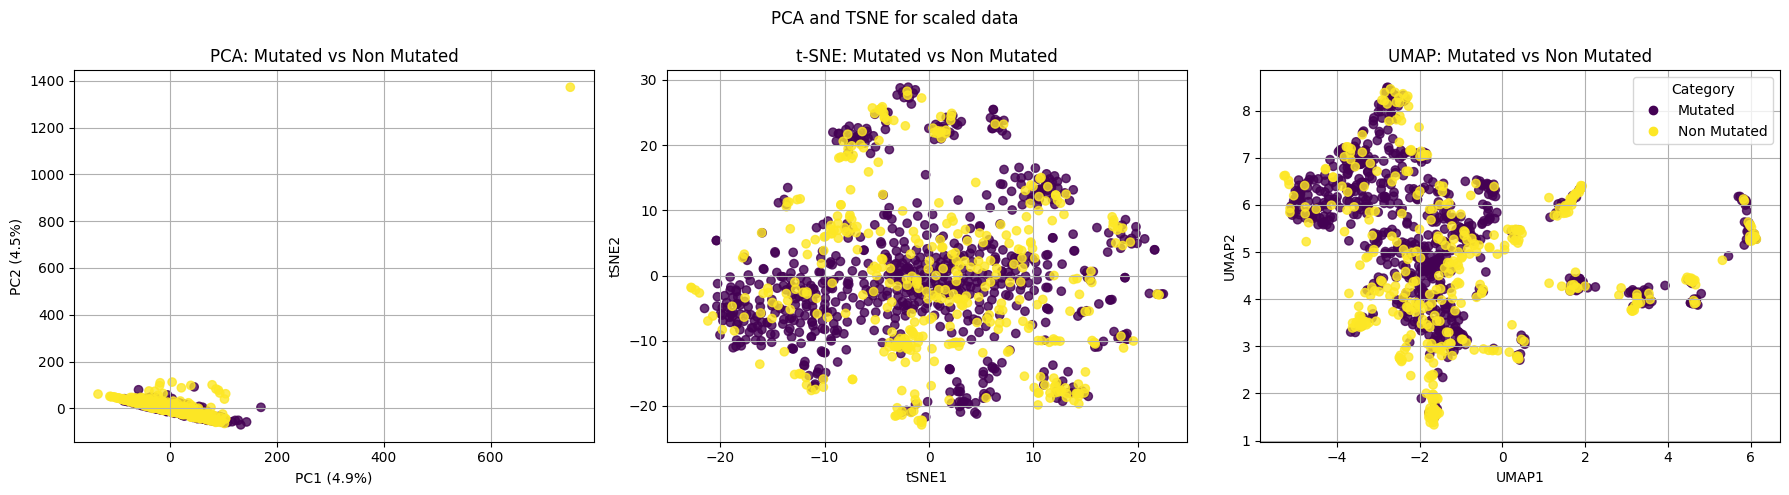

In [24]:
plot_PCA_tsne_umap(mRNA_2019_scaled,mutated_samples,non_mutated_samples,'PCA and TSNE for scaled data', categories=['Mutated','Non Mutated'])

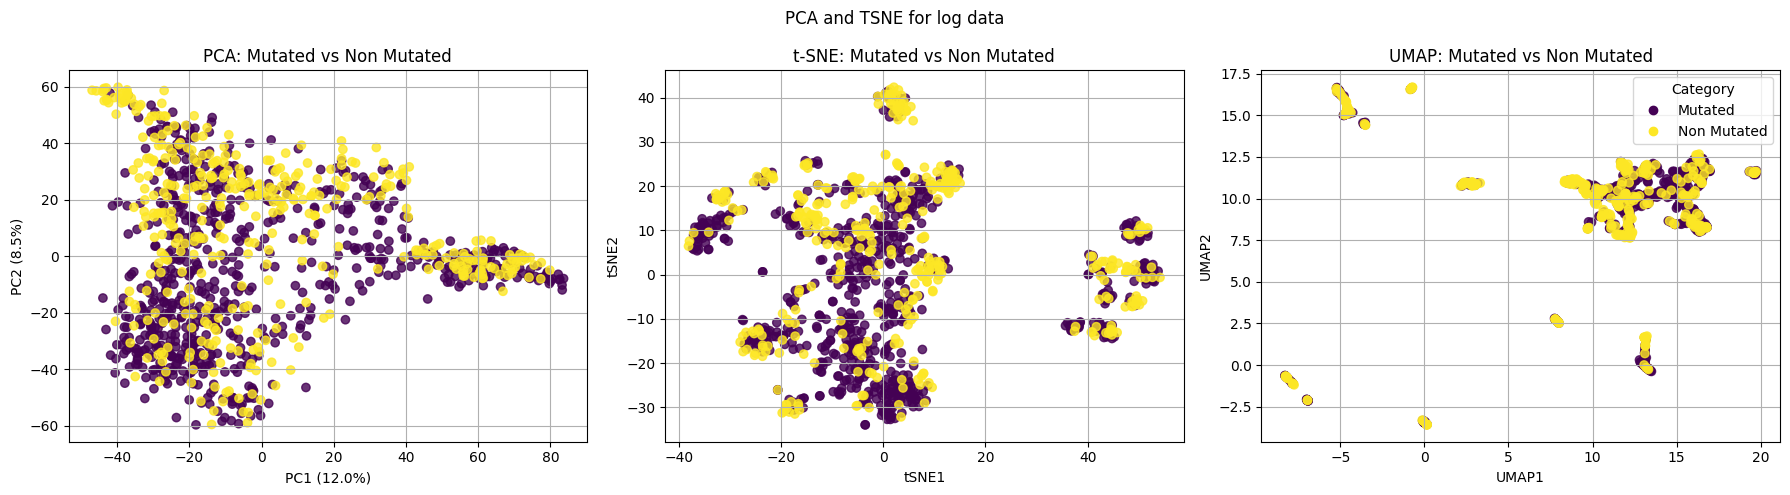

In [25]:
plot_PCA_tsne_umap(mRNA_2019_ordered_log,mutated_samples,non_mutated_samples,'PCA and TSNE for log data', categories=['Mutated','Non Mutated'])

### Visualizing Class Separability: Mutated vs Non-Mutated Samples

The plots above illustrate the separation between **mutated** and **non-mutated** samples using three different versions of the gene expression data:

1. **Raw bulk RNA-seq data**  
2. **Standardized log-transformed data**
3. **Log-transformed data** (`log(1 + x)`)  

Each representation was projected into two dimensions using **PCA**, **t-SNE**, and **UMAP**.

#### Observations:

- Across all three representations, **no clear linear separation** between mutated and non-mutated samples is visible in 2D space.
- The PCA plots suggest that variance explained by the first two components is limited, and outliers dominate raw data projections.
- t-SNE and UMAP show **better local structure**, but the clusters still contain a mix of both classes, indicating **low separability** in low-dimensional embeddings.

#### Interpretation:

Although 2D projections don’t reveal strong class separation, this does **not rule out higher-dimensional separability**. Many real-world classification problems require more than two components for effective discrimination.

To rigorously assess whether the mutation status can be predicted from gene expression, we will train **machine learning classifiers** on the high-dimensional data and evaluate their performance using appropriate metrics (e.g., accuracy, ROC AUC).


In [26]:
mRNA_final.to_csv('../DATA/ccle_2019/CCLE_2019_filtered.csv')

## Dataset Building

In [27]:
X = mRNA_final.T
y = mut_all_2019.Variant_Type

To reduce the high dimensionality of our gene expression dataset, we focused on a curated list of TP53 target genes—genes whose expression is directly regulated by the TP53 protein—sourced from tp53.cancer.gov/target_genes. By intersecting this list with the genes identified in our analysis, we aimed to retain biologically relevant features while ensuring a more feasible and interpretable approach to modeling.

In [ ]:
tp53_targets = [
    'CDKN1A', 'ABCA12', 'NTPCR', 'PGPEP1', 'RNF19B', 'LCE1E', 'EPN3', 'SCN4B', 'ARVCF', 'FCHO2',
    'PANK2', 'TMEM8B', 'RRM2B', 'ANKRA2', 'ORAI3', 'PLCL2', 'SAC3D1', 'LIMK2', 'FBXO32', 'SCRIB',
    'BHLHE40', 'FCHSD2', 'PAQR7', 'TP53', 'MDM2', 'CCNG1', 'PRKAB1', 'PMAIP1', 'SYTL1', 'LRP1',
    'FHL2', 'SEMA3B', 'BMP7', 'FLRT2', 'PCBP4', 'TP53I11', 'SUSD6', 'CYFIP2', 'PTP4A1', 'PRDM1',
    'TNFRSF10A', 'MCC', 'HES2', 'SLC25A45', 'BORCS7', 'GBE1', 'PERP', 'TRAK1', 'GDF15', 'DRAM1',
    'SESN2', 'RAP2B', 'TNFRSF10D', 'NUPR1', 'KCNN4', 'SLC44A5', 'BTBD10', 'GPC1', 'PLLP', 'TRIP6',
    'BTG2', 'FBXO22', 'SLC30A1', 'RRAD', 'TSPAN11', 'PARD6G', 'KLHDC7A', 'SLC4A11', 'BTG3', 'HES1',
    'POU3F1', 'TSGA10', 'DDB2', 'ISCU', 'SPATA18', 'ZNF219', 'VWCE', 'PHPT1', 'LMNA', 'SLC9A1',
    'C17orf89', 'HRAS', 'PPFIBP1', 'UNC5B', 'GADD45A', 'PHLDA3', 'TGFA', 'ZNF337', 'DDIT4', 'PIDD1',
    'MLF2', 'STAT3', 'CAPN2', 'HSD17B3', 'PPM1J', 'UQCC1', 'PLK3', 'SERPINB5', 'TLR3', 'ACTA2',
    'RAD51C', 'PML', 'MR1', 'STK17A', 'CASP6', 'ICOSLG', 'PPP4R3A', 'VDR', 'TIGAR', 'SERTAD1',
    'TM7SF3', 'EDN2', 'SERPINE1', 'PTPRE', 'MYO6', 'STX6', 'CATSPERG', 'IGFBP7', 'PTAFR', 'YPEL3',
    'RPS27L', 'TRAF4', 'TMEM68', 'ALOX5', 'TNFAIP8', 'PVRL4', 'NEFL', 'TP73', 'CAV1', 'IL1B',
    'RALGDS', 'ZNF195', 'TNFRSF10B', 'TRIM22', 'WDR63', 'ARHGEF3', 'TSKU', 'RETSAT', 'NKAIN4',
    'TRIM32', 'CCNK', 'ISYNA1', 'RBM38', 'ZNF385A', 'TRIAP1', 'CES2', 'ZNF561', 'CERS5', 'PCNA',
    'REV3L', 'PCLO', 'TRIM38', 'CFLAR', 'JAG1', 'RGL1', 'ZNF488', 'ZMAT3', 'CMBL', 'ZNF79',
    'DDR1', 'ACYP2', 'RNASE7', 'PDE4C', 'TRIM5', 'CGB7', 'KRT8', 'RGS20', 'BAX', 'FBXW7',
    'ASCC3', 'DHRS3', 'APAF1', 'SFN', 'PGAP1', 'TYMSOS', 'CHST14', 'KSR1', 'RHOC', 'PGF',
    'HSPA4L', 'ACER2', 'DUSP14', 'APOBEC3H', 'TNFRSF10C', 'PLCXD2', 'AKAP9', 'COBLL1', 'LACC1',
    'RPS19', 'POLH', 'KITLG', 'ANXA4', 'E2F7', 'BCL2L1', 'TRIML2', 'PLEKHF1', 'CCDC51', 'CPEB2',
    'LPXN', 'SARS', 'PPM1D', 'SLC12A4', 'APOBEC3C', 'EPS8L2', 'BCL6', 'VCAN', 'PLTP', 'CDH8',
    'CPSF4', 'LRPAP1', 'SCIN', 'SULF2', 'ATF3', 'ASTN2', 'FAM210B', 'BLCAP', 'ADCK3', 'PLXNB1',
    'DUSP11', 'DNAJB2', 'MFAP3L', 'SCN3B', 'XPC', 'BBC3', 'CD82', 'GLS2', 'C17orf82', 'AK3',
    'PLXNB2', 'GCC2', 'DOCK8', 'MKNK2', 'SDC4', 'AEN', 'CCDC90B', 'CDIP1', 'GPX1', 'COL7A1',
    'ALDH1A3', 'PRKAB2', 'METTL8', 'DUSP5', 'MON2', 'SDPR', 'BLOC1S2', 'DYRK3', 'CPE', 'GRHL3',
    'CPEB4', 'BBS2', 'PRKX', 'PPP1R3C', 'DUSP7', 'MRPL49', 'SMAD3', 'FAS', 'EDA2R', 'CSF1',
    'HHAT', 'CSNK1G1', 'BTG1', 'PRODH', 'STEAP3', 'EBI3', 'MYBPHL', 'SNX2', 'GPR87', 'EPHA2',
    'DCP1B', 'IGDCC4', 'DGKA', 'CEL', 'PTPRU', 'ABHD4', 'EFNB1', 'MYLK', 'SOCS4', 'NINJ1',
    'FAM13C', 'ENC1', 'IKBIP', 'FAM49A', 'CLCA2', 'RGMA', 'ABTB2', 'EI24', 'MYOF', 'TAB3',
    'PLK2', 'FAM198B', 'FOSL1', 'LAPTM5', 'FAM84B', 'CLDN1', 'RGS16', 'ADGRG1', 'EML2', 'NFKBIA',
    'TCAIM', 'PSTPIP2', 'FAM212B', 'FUCA1', 'MAST4', 'GNAI1', 'CLP1', 'RND3', 'AIFM2', 'ENPP2',
    'NHLH2', 'TEP1', 'SESN1', 'FDXR', 'IER5', 'MICALL1', 'INPP1', 'CROT', 'RNF144B', 'AMOTL1',
    'ETV7', 'NLRP1', 'TET2', 'TP53I3', 'LIF', 'PADI4', 'NOTCH1', 'ITGA3', 'CYP4F3', 'S100A2',
    'AMZ2', 'FAM196A', 'NYNRIN', 'TEX9', 'TP53INP1', 'NADSYN1', 'PANK1', 'RABGGTA', 'KRT15',
    'DAPK1', 'SCN2A', 'ARC', 'FAM98C', 'P3H2', 'TMEM63B'
]

genes_in_data = X.columns.to_list()

#Filter the TP53 target genes to include only the ones in the data
tp53_targets_final=list(set(tp53_targets).intersection(genes_in_data))

X = X[tp53_targets_final]

In [29]:
# Check that X and y are aligned with the same samples in the same order
assert all(X.index == y.index), "Sample mismatch between features and labels!"


# Train/test split
X_train, X_test, y_train_initial, y_test_initial = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train = y_train_initial.map(lambda x: 0 if x == 'WT' else 1)
y_test = y_test_initial.map(lambda x: 0 if x == 'WT' else 1)

print(f"Training data shape: {X_train.shape}")
print(f"Training labels distribution: {y_train.value_counts()}")
print()
print(f"Testing data shape: {X_test.shape}")
print(f"Testing labels distribution: {y_test.value_counts()}")

In [30]:
print("Train:",X_train.shape)
print("Test:",X_test.shape)
print("Train:",y_train.shape)
print("Test:",y_test.shape)

Train: (893, 335)
Test: (224, 335)
Train: (893,)
Test: (224,)


In [ ]:
print(y_train_initial.shape)
print(y_test_initial.shape)

In [31]:
# Save all the dataframes and arrays
X_train.to_csv('../DATA/ccle_2019/X_train.csv')
X_test.to_csv('../DATA/ccle_2019/X_test.csv')

y_train_initial.to_csv('../DATA/ccle_2019/y_train_initial.csv')
y_test_initial.to_csv('../DATA/ccle_2019/y_test_initial.csv')

y_train.to_csv('../DATA/ccle_2019/y_train.csv')
y_test.to_csv('../DATA/ccle_2019/y_test.csv')
